# Model Distillation
## AIAT 122 – Deep Learning

## Learning objectives
- Train a small **student** model to mimic a larger **teacher** using soft labels.
- Compare teacher vs student accuracy and size.

**Where is this used in real life?** Deploying big models on phones or edge is costly. **We use distillation to get a small student that mimics the teacher** instead of only training a small model from hard labels because the teacher’s soft probabilities carry more information (e.g. “maybe class 2”) than one-hot labels.

**Prerequisites:** Basic TensorFlow/Keras. If TensorFlow import fails, see DOCS/COLAB_SETUP.md.


## Short theory
- **Distillation:** Train a small student to match the **soft outputs** (probabilities) of a trained teacher.
- **Soft labels:** Teacher outputs P(class) instead of one-hot; student learns from these (often with temperature T to soften further).
- **Why we use distillation:** A small network can approximate the teacher’s behavior and run faster; soft labels help the student generalize.

## Inputs & Outputs
**Inputs:** TensorFlow, synthetic or small dataset, teacher and student models.  
**Dataset:** Synthetic — random data (no download; used to demonstrate distillation).  
**Outputs:** Trained teacher and student, accuracy of both, and a bar chart comparing them. Run time: under ~5 min (few epochs).


In [1]:
import numpy as np
import matplotlib.pyplot as plt
try:
    import tensorflow as tf
    print("TensorFlow version:", tf.__version__)
except Exception as e:
    err = str(e).lower()
    if "charset_normalizer" in err or "md__mypyc" in err or "partially initialized" in err:
        print("⚠️ Fix: pip install --upgrade charset-normalizer requests, then restart kernel.")
        raise RuntimeError("Fix: pip install --upgrade charset-normalizer requests, then restart kernel.") from e
    raise
print("✅ Imports OK.")

TensorFlow version: 2.13.0
✅ Imports OK.


### Step 1: Build and train teacher (larger model)

In [2]:
# Synthetic 3-class data; we use 3 epochs so it runs in ~2 min
np.random.seed(42)
X = np.random.randn(800, 20).astype(np.float32)
y_hard = (X[:, :3].argmax(axis=1)).astype(np.int32)  # 0,1,2
y_cat = tf.keras.utils.to_categorical(y_hard, 3)

teacher = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation="relu", input_shape=(20,)),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(3, activation="softmax"),
])
teacher.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
teacher.fit(X, y_cat, epochs=3, verbose=1)
acc_teacher = teacher.evaluate(X, y_cat, verbose=0)[1]
print(f"Teacher accuracy: {acc_teacher:.4f}")

Epoch 1/3
25/25 [==============================] - 0s 397us/step - loss: 1.1152 - accuracy: 0.3750
Epoch 2/3
25/25 [==============================] - 0s 307us/step - loss: 0.9091 - accuracy: 0.6250
Epoch 3/3
25/25 [==============================] - 0s 293us/step - loss: 0.7529 - accuracy: 0.7513
Teacher accuracy: 0.8025


### Step 2: Get soft labels and train student (smaller model)

In [3]:
# We use soft labels from the teacher (instead of hard one-hot) so the student learns relative confidence
soft_labels = teacher.predict(X, verbose=0)

student = tf.keras.Sequential([
    tf.keras.layers.Dense(16, activation="relu", input_shape=(20,)),
    tf.keras.layers.Dense(3, activation="softmax"),
])
student.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
student.fit(X, soft_labels, epochs=3, verbose=1)
acc_student = student.evaluate(X, y_cat, verbose=0)[1]
print(f"Student accuracy (trained on soft labels): {acc_student:.4f}")
print("After this cell you should see: student accuracy often close to teacher despite smaller size.")

Epoch 1/3
25/25 [==============================] - 0s 309us/step - loss: 1.2632 - accuracy: 0.3212
Epoch 2/3
25/25 [==============================] - 0s 301us/step - loss: 1.1954 - accuracy: 0.3537
Epoch 3/3
25/25 [==============================] - 0s 273us/step - loss: 1.1478 - accuracy: 0.4025
Student accuracy (trained on soft labels): 0.4038
After this cell you should see: student accuracy often close to teacher despite smaller size.


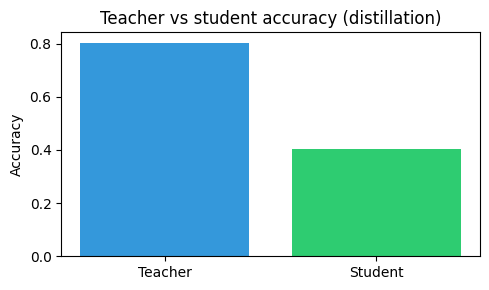

In [4]:
# Compare teacher vs student accuracy
fig, ax = plt.subplots(1, 1, figsize=(5, 3))
ax.bar(["Teacher", "Student"], [acc_teacher, acc_student], color=["#3498db", "#2ecc71"])
ax.set_ylabel("Accuracy")
ax.set_title("Teacher vs student accuracy (distillation)")
plt.tight_layout()
plt.show()

## 🧩 Mini-exercise | تمرين مصغر

**Try it:** Change the temperature (e.g. 2.0 → 4.0) when computing soft labels and retrain the student. Does the student accuracy change?

---

## Summary
**What you did:** Trained a teacher (larger) and a student (smaller) on synthetic data; the student learned from the teacher’s soft outputs and achieved comparable accuracy.

**In real life you'd also:** Use temperature scaling for softer distributions, mix soft and hard labels, and deploy only the student.

**The main idea:** Distillation transfers knowledge from a large teacher to a small student via soft labels.

**Next:** `07_model_optimization_quantization.ipynb` shows quantization to reduce model size and speed.